# Experimento 10 — Stemming sobre el modelo del experimento 4

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook **vuelve al modelo del experimento 4** (`experimento4.ipynb`): un solo nivel, con detector de opinión,
TF-IDF por partes y un clasificador lineal. Los experimentos 6 a 9 usan un modelo en dos niveles (stacking) que no
corresponde a lo visto en clase, por lo que no se toman como base. La sección 1 repite de forma resumida la
configuración común (misma semilla, mismo split y mismos folds). Los experimentos anteriores **no se vuelven a
ejecutar**: sus métricas se registran como valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 10 — Stemming

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de experimentos anteriores tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 2, "descripcion": "TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
     "mejores_params": {"clf__C": 10}, "acc_train": 0.9999, "acc_cv": 0.8865, "std_cv": 0.0099, "f1_cv": 0.8908,
     "acc_test": 0.8992, "f1_test": 0.9031, "envio": "submission_02.csv", "kaggle_publico": 0.88},
    {"experimento": 4, "descripcion": "Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC",
     "mejores_params": {"clf": "LinearSVC", "clf__C": 0.2}, "acc_train": 0.9770, "acc_cv": 0.9009, "std_cv": 0.0057,
     "f1_cv": 0.9055, "acc_test": 0.8975, "f1_test": 0.9021, "envio": "submission_04.csv", "kaggle_publico": None},
    {"experimento": 9, "descripcion": "Dos niveles con corrección de tipeo: SVM RBF (no se usa como base: stacking)",
     "acc_cv": 0.9065, "std_cv": 0.0086, "acc_test": 0.9029, "envio": "submission_09.csv", "kaggle_publico": 0.91555},
]:
    resultados.append(fila)

# Experimento 4 (experimento4.ipynb, sección 2.4): accuracy por fold con los mismos folds, y accuracy de entrenamiento
ACC_FOLDS_E4 = np.array([0.9021, 0.9010, 0.9052, 0.9062, 0.8901])
ACC_TRAIN_E4 = 0.9770

# Prueba de robustez en test del experimento 4 (experimento5.ipynb, sección 2.8)
ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 4", "escenario": "Original", "accuracy": 0.8975},
    {"modelo": "Exp. 4", "escenario": "Oraciones desordenadas", "accuracy": 0.7358},
    {"modelo": "Exp. 4", "escenario": "Última oración al inicio", "accuracy": 0.5946},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88000
2,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
3,9,Dos niveles con corrección de tipeo: SVM RBF (no se usa como base: stacking),NaN,NaN,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,0.91555


## 2. Experimento 10 — Stemming

**Motivación:** al elegir el modelo final por el score público (experimento 9) se corre el riesgo de ajustarse al
ruido del leaderboard: los envíos 7 y 9 están empatados en validación y difieren en muy pocas predicciones. Por eso
se decide buscar un modelo **de mejor calidad y sin caer en el overfitting**, decidiendo solo con la validación cruzada.
Se parte del experimento 4, que es el mejor modelo de un nivel antes del stacking.

En ese modelo cada forma de una palabra es una feature distinta: `recomiendo`, `recomendaria` y `recomendable` no
comparten nada, aunque expresan lo mismo. Con 9.600 reseñas, muchas de esas formas aparecen pocas veces y su peso se
estima mal.

**Idea:** aplicar **stemming** (reducir cada palabra a su raíz) antes de construir el TF-IDF, para que las variantes
de una misma palabra compartan una sola feature. 

**Hipótesis:** al juntar variantes, cada feature tiene más ejemplos, el vocabulario se reduce y la accuracy de
validación sube (o se mantiene con menos features).

**Proceso:**
1. Definir el stemmer y revisar qué palabras junta.
2. Ablación 2 × 2 con CV: stemming y corrección de tipeo (la del experimento 9), por separado y juntos, fold por fold
   contra el experimento 4.
3. Modelo del experimento 10: `GridSearchCV` con el clasificador como hiperparámetro.
4. Evaluación en test, coeficientes, prueba de robustez y envío.

### 2.1 Definiciones del experimento 4

Las mismas funciones (segmentación, evasivas, conectores) y el transformador `PartesE5` de `experimento5.ipynb`. Con
sus parámetros por defecto es **idéntico** al `PartesConOpinion` del experimento 4: el detector de opinión se
entrena en `fit`, dentro del pipeline, y en cada fold solo ve las reseñas de entrenamiento.

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

### 2.2 Stemmer

Se usa el **Snowball** para español de `nltk` (`SnowballStemmer("spanish")`), un algoritmo de reglas: quita sufijos
de género, número, conjugación y derivación. No se entrena con los datos, así que no puede haber leakage.

**Dónde se aplica:** dentro del tokenizador de los TF-IDF de las tres partes del modelo, **no** sobre el texto
antes del pipeline. Las listas de conectores y de frases evasivas (`aun asi`, `todavia no me decido`...) y la
segmentación en oraciones buscan las palabras completas; si el texto llegara ya reducido a raíces, dejarían de
funcionar. El detector de opinión se deja sin stemming, para cambiar una sola cosa respecto al experimento 4.

In [8]:
from nltk.stem import SnowballStemmer

STEMMER = SnowballStemmer("spanish")
PATRON_TOKEN = re.compile(r"(?u)\b\w\w+\b")       # el mismo patrón de palabras que usa TfidfVectorizer por defecto
_RAICES = {}                                         # caché palabra -> raíz (el stemmer es lento palabra por palabra)


def raiz(palabra):
    if palabra not in _RAICES:
        _RAICES[palabra] = STEMMER.stem(palabra)
    return _RAICES[palabra]


def tokenizar_con_stemming(texto):
    """Tokenizador para TfidfVectorizer: mismas palabras que el tokenizador por defecto, reducidas a su raíz."""
    return [raiz(p) for p in PATRON_TOKEN.findall(texto)]


def tfidf_partes(stemming=False, min_df=2):
    """TF-IDF de una parte de la reseña. Igual al del experimento 4, con stemming opcional."""
    if stemming:
        return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True,
                               tokenizer=tokenizar_con_stemming, token_pattern=None)
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


ejemplos = ["recomiendo", "recomendaria", "recomendable", "decepciono", "decepcionante", "decepcionado",
            "comodo", "comoda", "comodisima", "incomodo", "malo", "mala", "malisimo", "mal",
            "excelente", "excelentes", "funciona", "funciono", "funcionando"]
pd.DataFrame({"palabra": ejemplos, "raíz": [raiz(p) for p in ejemplos]}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
palabra,recomiendo,recomendaria,recomendable,decepciono,decepcionante,decepcionado,comodo,comoda,comodisima,incomodo,malo,mala,malisimo,mal,excelente,excelentes,funciona,funciono,funcionando
raíz,recom,recomendari,recomend,decepcion,decepcion,decepcion,comod,comod,comodisim,incomod,mal,mal,malisim,mal,excelent,excelent,funcion,funcion,funcion


In [9]:
# Efecto sobre el vocabulario de X_train y familias de palabras que quedan juntas
palabras = Counter(p for t in X_train for p in PATRON_TOKEN.findall(t))
familias = {}
for p in palabras:
    familias.setdefault(raiz(p), []).append(p)

print(f"Palabras distintas: {len(palabras):,} -> raíces distintas: {len(familias):,} "
      f"({1 - len(familias) / len(palabras):.0%} menos)")
print(f"Palabras que aparecen una sola vez: {sum(f == 1 for f in palabras.values()):,} -> raíces que aparecen una "
      f"sola vez: {sum(sum(palabras[p] for p in ps) == 1 for ps in familias.values()):,}")

raices_demo = ["recomend", "decepcion", "comod", "defectu", "funcion", "excelent", "mal", "par"]
pd.DataFrame([{"raíz": r, "palabras que junta (frecuencia)":
               ", ".join(f"{p} ({palabras[p]})" for p in sorted(familias.get(r, []), key=palabras.get, reverse=True)[:8])}
              for r in raices_demo])

Palabras distintas: 4,998 -> raíces distintas: 2,897 (42% menos)
Palabras que aparecen una sola vez: 2,011 -> raíces que aparecen una sola vez: 1,069


,raíz,palabras que junta (frecuencia)
0,recomend,"recomendar (79), recomendado (22), recomendo (22), recomendandolo (1)"
1,decepcion,"decepciono (225), decepcionante (127), decepcionado (3)"
2,comod,"comodidad (206), comoda (75), comodo (61)"
3,defectu,"defectuoso (52), defectuosa (52)"
4,funcion,"funciona (866), funcionando (431), funciones (36), funcionaba (22), funcionan (18), funciono (17), funcionar (11), funcionara (7)"
5,excelent,excelente (97)
6,mal,"mal (445), mala (107), malo (100)"
7,par,"para (6463), par (1497), parar (368), pare (108), pared (41), parado (3), paro (2), parada (1)"


**Lectura**

- El stemmer junta lo que se esperaba: `decepciono`, `decepcionante` y `decepcionado` quedan en `decepcion`; `mal`,
  `mala` y `malo` en `mal`; `comodo`, `comoda` y `comodidad` en `comod`. El vocabulario de `X_train` baja de 4.998
  palabras a 2.897 raíces (−42 %), y las que aparecen una sola vez de 2.011 a 1.069.
- **No junta todo.** Los verbos con cambio de raíz quedan separados (`recomiendo` → `recom`, `recomendar` →
  `recomend`) y los superlativos también (`malisimo` → `malisim`, `comodisima` → `comodisim`). Una causa probable es
  que la normalización base quita las tildes, y varias reglas del Snowball para español se apoyan en ellas
  (`recomendaria` queda en `recomendari`).
- **Junta de más en palabras cortas:** la raíz `par` reúne `para`, `par`, `parar`, `pare` y `pared`. Son palabras sin
  carga de sentimiento, así que el costo esperado es bajo.
- `incomodo` conserva su propia raíz (`incomod`), distinta de `comod`: el stemming no mezcla la palabra con su
  contraria.

### 2.3 Ablación: stemming y corrección de tipeo

El stemming y el corrector de tipeo del experimento 9 atacan el mismo problema (formas distintas de una misma
palabra) por caminos distintos: el corrector junta `reslto` con `resulto`; el stemming junta `resulto` con
`resultaron`. Se miden por separado y juntos sobre el modelo del experimento 4 (LinearSVC, `C = 0,2`), con los mismos
5 folds. Para cada variante se guarda también la accuracy de **entrenamiento**: la brecha entre entrenamiento y
validación es la medida de sobreajuste.

El corrector (`CorrectorTipeo`) es el mismo de `experimento9.ipynb` (sección 2.2): se ajusta sin etiquetas con los
textos de entrenamiento de cada fold y va como primer paso del pipeline.

In [10]:
from collections import Counter

LETRAS = "abcdefghijklmnopqrstuvwxyzñ"
PATRON_PALABRA = re.compile(r"[a-zñ]+")


def ediciones_distancia_1(palabra):
    """Todas las cadenas a distancia de edición 1: borrado, transposición, sustitución e inserción."""
    cortes = [(palabra[:i], palabra[i:]) for i in range(len(palabra) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transposiciones = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituciones = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    inserciones = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transposiciones + sustituciones + inserciones)


class CorrectorTipeo(BaseEstimator, TransformerMixin):
    """Reemplaza palabras raras por la palabra frecuente más parecida (distancia de edición 1)."""

    def __init__(self, max_rara=2, min_frecuente=15, min_largo=4):
        self.max_rara = max_rara
        self.min_frecuente = min_frecuente
        self.min_largo = min_largo

    def fit(self, X, y=None):
        self.frecuencias_ = Counter(p for texto in X for p in PATRON_PALABRA.findall(texto))
        self.frecuentes_ = {p: f for p, f in self.frecuencias_.items() if f >= self.min_frecuente}
        self.correcciones_ = {}
        for palabra, f in self.frecuencias_.items():
            if f <= self.max_rara and len(palabra) >= self.min_largo:
                candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
                if candidatas:
                    self.correcciones_[palabra] = max(candidatas, key=self.frecuentes_.get)
        return self

    def _corregir(self, palabra):
        if palabra in self.correcciones_:
            return self.correcciones_[palabra]
        if palabra not in self.frecuencias_ and len(palabra) >= self.min_largo:   # palabra nunca vista en train
            candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
            if candidatas:
                return max(candidatas, key=self.frecuentes_.get)
        return palabra

    def transform(self, X):
        return [PATRON_PALABRA.sub(lambda m: self._corregir(m.group()), texto) for texto in X]

In [11]:
COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]


def pipeline_e10(stemming=False, corrector=False, clf=None):
    """Modelo del experimento 4 con stemming y corrector de tipeo opcionales."""
    pasos = [("corrector", CorrectorTipeo())] if corrector else []
    pasos += [
        ("partes", PartesE5()),
        ("tfidf", ColumnTransformer([(c, tfidf_partes(stemming=stemming), c) for c in COLUMNAS_PARTES])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ]
    return Pipeline(pasos)


from sklearn.model_selection import cross_validate

VARIANTES = {
    "A. Stemming": {"stemming": True},
    "B. Corrector de tipeo": {"corrector": True},
    "C. Corrector + stemming": {"stemming": True, "corrector": True},
}
filas = {"[ref. exp. 4]": {"acc_folds": ACC_FOLDS_E4, "acc_train": ACC_TRAIN_E4, "features": 42177}}
for nombre, variante in VARIANTES.items():
    cv = cross_validate(pipeline_e10(**variante), X_train, y_train, cv=skf, return_train_score=True, n_jobs=-1)
    n_features = pipeline_e10(**variante).fit(X_train, y_train)[:-1].transform(X_train.iloc[:5]).shape[1]
    filas[nombre] = {"acc_folds": cv["test_score"], "acc_train": cv["train_score"].mean(), "features": n_features}

ablacion = pd.DataFrame({
    "features": {k: v["features"] for k, v in filas.items()},
    "acc_train": {k: v["acc_train"] for k, v in filas.items()},
    "acc_cv": {k: v["acc_folds"].mean() for k, v in filas.items()},
    "std": {k: v["acc_folds"].std() for k, v in filas.items()},
    "brecha train-cv": {k: v["acc_train"] - v["acc_folds"].mean() for k, v in filas.items()},
    "diferencia con exp. 4": {k: v["acc_folds"].mean() - ACC_FOLDS_E4.mean() for k, v in filas.items()},
    "folds que gana al exp. 4": {k: int((np.round(v["acc_folds"], 4) > ACC_FOLDS_E4).sum()) for k, v in filas.items()},
}).round(4)
ablacion

,features,acc_train,acc_cv,std,brecha train-cv,diferencia con exp. 4,folds que gana al exp. 4
[ref. exp. 4],42177,0.9770,0.9009,0.0057,0.0761,0.0000,0
A. Stemming,37360,0.9776,0.9027,0.0074,0.0749,0.0018,3
B. Corrector de tipeo,42122,0.9775,0.9020,0.0061,0.0755,0.0011,3
C. Corrector + stemming,37312,0.9777,0.9030,0.0064,0.0746,0.0021,3


In [12]:
por_fold = pd.DataFrame({k: v["acc_folds"] for k, v in filas.items()}, index=[f"fold {k}" for k in range(1, 6)]).T
por_fold["media"] = por_fold.mean(axis=1)
por_fold.round(4)

,fold 1,fold 2,fold 3,fold 4,fold 5,media
[ref. exp. 4],0.9021,0.9010,0.9052,0.9062,0.8901,0.9009
A. Stemming,0.9094,0.9000,0.9021,0.9115,0.8906,0.9027
B. Corrector de tipeo,0.9052,0.9026,0.9052,0.9068,0.8901,0.9020
C. Corrector + stemming,0.9099,0.8995,0.9016,0.9104,0.8938,0.9030


**Lectura**

- **Ninguna variante supera el ruido entre folds.** Las tres mejoran la media entre +0,11 y +0,21 puntos, con una
  desviación entre folds de 0,6–0,7 puntos.
- **Stemming (A):** +0,18 puntos, pero gana solo 3 de 5 folds: sube en los folds 1 y 4 y baja en el 2 y el 3. No es
  una mejora consistente.
- **Corrector de tipeo (B):** +0,11 puntos; gana 3 folds y empata los otros 2. Nunca empeora, pero casi no cambia
  nada.
- **Juntos (C):** 0,9030, prácticamente igual que el stemming solo. Los dos efectos no se suman, lo que es coherente
  con que ataquen el mismo problema.
- **El número de features baja poco** con el stemming (42.177 → 37.360, −11 %), aunque el vocabulario bajó 42 %: la
  mayoría de las features son **bigramas**, y dos raíces juntas siguen siendo combinaciones poco repetidas.
- **El sobreajuste no cambia:** la brecha entre entrenamiento y validación es de ≈ 7,5 puntos en todas las variantes.
  El stemming no le quita capacidad al modelo.

**Decisión:** se continúa con la variante **A (solo stemming)**, que es el objeto del experimento. La variante C
tiene la misma accuracy con un paso más en el pipeline; ante un empate se prefiere lo más simple.

### 2.4 Modelo del experimento 10

Se usa el experimento 4 con **stemming** (variante A). Como en los experimentos 4 y 5, el clasificador es un
hiperparámetro: `GridSearchCV` compara regresión logística y LinearSVC, cada uno con su propia grilla de `C`, sobre
los mismos folds (el `C` óptimo puede cambiar al cambiar las features).

In [13]:
busqueda_e10 = GridSearchCV(
    pipeline_e10(stemming=True),
    [
        {"clf": [LinearSVC(max_iter=5000, random_state=SEED)], "clf__C": [0.1, 0.2, 0.5]},
        {"clf": [LogisticRegression(max_iter=3000, random_state=SEED)], "clf__C": [1, 3]},
    ],
    cv=skf, scoring=SCORING, refit="accuracy", return_train_score=True, n_jobs=-1,
)
busqueda_e10.fit(X_train, y_train)

mejor = busqueda_e10.best_params_
print(f"Mejor clasificador: {type(mejor['clf']).__name__} | C = {mejor['clf__C']}")
print(f"Accuracy CV: {busqueda_e10.best_score_:.4f}")
tabla_e10 = tabla_cv(busqueda_e10)
tabla_e10.insert(0, "clasificador", tabla_e10["params"].map(lambda p: type(p["clf"]).__name__))
tabla_e10.insert(1, "C", tabla_e10.pop("params").map(lambda p: p["clf__C"]))
tabla_e10["brecha"] = (tabla_e10["acc_train"] - tabla_e10["acc_cv"]).round(4)
tabla_e10

Mejor clasificador: LinearSVC | C = 0.2
Accuracy CV: 0.9027


,clasificador,C,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste,brecha
1,LinearSVC,0.2,0.9776,0.9027,0.0074,0.9071,14.5430,0.0749
2,LinearSVC,0.5,0.9955,0.9003,0.0074,0.9049,14.9407,0.0952
0,LinearSVC,0.1,0.9592,0.9002,0.0067,0.9046,14.8217,0.0590
3,LogisticRegression,1.0,0.9776,0.8996,0.0079,0.9041,16.0619,0.0780
4,LogisticRegression,3.0,0.9959,0.8986,0.0091,0.9033,9.4903,0.0973


In [14]:
i = busqueda_e10.best_index_
ACC_FOLDS_E10 = np.array([busqueda_e10.cv_results_[f"split{k}_test_accuracy"][i] for k in range(5)])
comparacion = pd.DataFrame({"[ref. exp. 4]": ACC_FOLDS_E4, "exp. 10": ACC_FOLDS_E10},
                           index=[f"fold {k}" for k in range(1, 6)]).T
comparacion["media"] = comparacion.mean(axis=1)
print("Folds en que el exp. 10 gana al exp. 4:", int((np.round(ACC_FOLDS_E10, 4) > ACC_FOLDS_E4).sum()), "de 5")
comparacion.round(4)

Folds en que el exp. 10 gana al exp. 4: 3 de 5


,fold 1,fold 2,fold 3,fold 4,fold 5,media
[ref. exp. 4],0.9021,0.901,0.9052,0.9062,0.8901,0.9009
exp. 10,0.9094,0.900,0.9021,0.9115,0.8906,0.9027


**Lectura**

- El mejor clasificador vuelve a ser **LinearSVC con `C = 0,2`**, igual que en el experimento 4: el stemming no
  cambia el punto óptimo de regularización. Accuracy de CV = 0,9027 ± 0,0074.
- La regresión logística queda algo por debajo (0,8996 con `C = 1`), como en los experimentos 4 y 5.
- Con `C = 0,1` la brecha baja de 7,5 a 5,9 puntos a cambio de 0,25 puntos de CV: regularizar más reduce el
  sobreajuste, pero no gratis. El experimento 11 busca una forma mejor de hacerlo.
- Frente al experimento 4 gana en **3 de 5 folds**, y la diferencia media (+0,18) es cuatro veces menor que la
  desviación entre folds: es un **empate técnico**.

### 2.5 Evaluación en test y coeficientes

Test -> accuracy: 0.9000 | F1 macro: 0.9046

              precision    recall  f1-score   support

    negativo      0.861     0.859     0.860       843
     neutral      0.989     1.000     0.994       715
    positivo      0.862     0.856     0.859       842

    accuracy                          0.900      2400
   macro avg      0.904     0.905     0.905      2400
weighted avg      0.900     0.900     0.900      2400



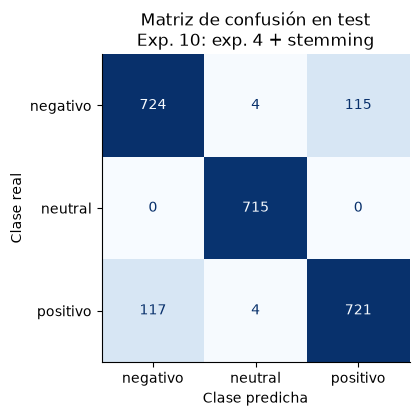

Negativo vs positivo en test: 0.858


In [15]:
metricas_e10 = evaluar_en_test(busqueda_e10.best_estimator_, "Exp. 10: exp. 4 + stemming")
np_test = (y_test != "neutral").to_numpy()
print(f"Negativo vs positivo en test: {(metricas_e10['pred'][np_test] == y_test.to_numpy()[np_test]).mean():.3f}")

In [16]:
# Raíces y bigramas de raíces con mayor peso por clase (el prefijo indica la parte de la reseña)
top_coeficientes(busqueda_e10.best_estimator_, n=12)

,negativo,neutral,positivo
0,ultima_op__mal (1.55),texto__vien (0.57),ultima_op__sobresalient (1.14)
1,tras_sin_ev__mal (1.40),ultima_op__todavi (0.52),ultima_op__confiabl (1.12)
2,tras_sin_ev__pobr (1.27),ultima_op__guard (0.51),ultima_op__practic (1.11)
3,ultima_op__inconsistent (1.25),texto__kil (0.51),tras_sin_ev__resistent (1.11)
4,ultima_op__poc fiabl (1.23),texto__tra (0.51),ultima_op__eficient (1.10)
5,ultima_op__delic (1.23),texto__paquet (0.50),ultima_op__decent (1.10)
6,ultima_op__ordinari (1.23),texto__el paquet (0.48),tras_sin_ev__formid (1.10)
7,ultima_op__incumplidor (1.23),ultima_op__lo (0.45),ultima_op__impec (1.09)
8,tras_sin_ev__imprecis (1.21),texto__la caj (0.45),ultima_op__buenisim (1.09)
9,tras_sin_ev__torp (1.20),texto__unidad (0.44),ultima_op__liger (1.09)


**Lectura**

- En test la accuracy es **0,9000** frente a 0,8975 del experimento 4: 6 reseñas de 2.400, muy por debajo del error
  estándar del test (≈ 0,006). Confirma el empate.
- `neutral` sigue resuelta (F1 0,994) y todo el error está entre `negativo` y `positivo` (0,858 de acierto entre esas
  dos clases).
- Los coeficientes son los esperables, ahora sobre raíces: `mal`, `pobr`, `ordinari`, `terribl`, `defectu` para
  `negativo`; `sobresalient`, `confiabl`, `eficient`, `impec`, `buenisim` para `positivo`; y raíces descriptivas
  (`paquet`, `caj`, `unidad`, `color`, `kil`) para `neutral`. Casi todos vienen de la **última oración con opinión**
  o del texto tras el último conector, como en el experimento 4.

### 2.6 Prueba de robustez en test

In [17]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 10", "escenario": e, "accuracy": accuracy_score(y_test, busqueda_e10.best_estimator_.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 10,Exp. 4
escenario,,
Original,0.9000,0.8975
Oraciones desordenadas,0.7358,0.7358
Última oración al inicio,0.5908,0.5946


### 2.7 Registro y envío

In [18]:
registrar_resultado(
    experimento=10,
    descripcion="Exp. 4 + stemming (Snowball) en los TF-IDF por partes, " + type(mejor["clf"]).__name__,
    busqueda=busqueda_e10,
    metricas_test=metricas_e10,
    envio="submission_10.csv",
)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88000
2,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
3,9,Dos niveles con corrección de tipeo: SVM RBF (no se usa como base: stacking),NaN,NaN,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,0.91555
4,10,"Exp. 4 + stemming (Snowball) en los TF-IDF por partes, LinearSVC","{'clf': LinearSVC(max_iter=5000, random_state=42), 'clf__C': 0.2}",0.9776,0.9027,0.0074,0.9071,0.9000,0.9046,submission_10.csv,NaN


In [19]:
envio_e10 = generar_envio(busqueda_e10, numero=10)

Envío guardado en envios/submission_10.csv y modelo en modelos/modelo_10.joblib
Distribución de predicciones en eval (%):
answer
negativo    35.4
neutral     27.7
positivo    37.0


### 2.8 Análisis del experimento 10

**Resultados:** accuracy de CV = **0,9027 ± 0,0074** (LinearSVC, `C = 0,2`) y accuracy en test = **0,9000**.

| | Exp. 4 | Exp. 10 |
|---|---|---|
| Preprocesamiento | — | Stemming (Snowball) |
| Features | 42.177 | 37.360 |
| Accuracy de entrenamiento | 0,9770 | 0,9776 |
| Accuracy CV | 0,9009 ± 0,006 | **0,9027** ± 0,007 |
| Brecha entrenamiento − CV | 7,6 puntos | 7,5 puntos |
| Accuracy test | 0,8975 | **0,9000** |
| Test, oraciones desordenadas | 0,736 | 0,736 |
| Test, última oración al inicio | 0,595 | 0,591 |

1. **El stemming no mejora el modelo de forma demostrable.** La diferencia con el experimento 4 (+0,18 en CV, gana 3
   de 5 folds; +0,25 en test) está dentro del ruido. La hipótesis no se confirma.
2. **Por qué aporta tan poco:**
   - Las palabras de opinión de estas reseñas ya son frecuentes en cada una de sus formas (`decepciono` aparece 225
     veces y `decepcionante` 127): el modelo ya tenía ejemplos suficientes para estimar el peso de cada una por
     separado.
   - El stemmer deja sin juntar parte de lo que importaría (verbos con cambio de raíz, superlativos), en parte
     porque el texto llega sin tildes.
   - El error que queda no es de vocabulario sino de **estructura**: saber cuál de las opiniones de la reseña decide
     la etiqueta (experimentos 2 a 5). Juntar formas de una palabra no ayuda con eso.
3. **No reduce el sobreajuste:** la brecha se mantiene en ≈ 7,5 puntos. El modelo sigue teniendo unas 4 features por
   cada reseña de entrenamiento.
4. **No cambia la robustez:** la dependencia de la posición del veredicto es la misma del experimento 4.
5. **Lo que sí deja:** un vocabulario 42 % más pequeño y 11 % menos features sin perder accuracy. Es una base
   razonable para el siguiente paso.

**Decisión:** el experimento 10 es un **empate técnico** con el 4. Se registra y se genera `submission_10.csv` como
evidencia del proceso. Se usa como base del experimento 11 porque es
igual de bueno con menos features.

**Próximo paso (experimento 11):** atacar directamente el sobreajuste con **selección de features**, conservando
solo los n-gramas más asociados con la etiqueta.